<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Андрей! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Привет, Павел!</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Название проекта

## https://github.com/2Myaka2/DataScience_projects

### работал в репозитории

# Предсказание возрастной категории пользователей интернет-сервисов

## Описание проекта

Заказчиком проекта является IT-компания «Йети», которая управляет группой популярных интернет-сервисов и использует рекламную сеть для показа контекстной рекламы. Один из важных факторов эффективности рекламы — корректный возрастной таргетинг. Если рекламное объявление показывается неподходящей возрастной группе, это может снижать конверсию, ухудшать пользовательский опыт и приводить к финансовым или репутационным рискам.

Цель проекта — построить модель машинного обучения, которая по данным о поведении анонимных пользователей в интернете будет предсказывать их возрастную категорию.

Задача относится к задаче многоклассовой классификации. Целевая переменная — `age_category`, принимающая значения:

- `0` — младше 18 лет;
- `1` — 18–25 лет;
- `2` — 26–40 лет;
- `3` — 41–55 лет;
- `4` — 56+ лет.

В качестве признаков используются данные из нескольких источников:

- информация о посещениях сайтов пользователями;
- активность взаимодействия с рекламными объявлениями;
- глубина просмотра сайтов;
- основное устройство пользователя;
- использование облачных сервисов.

В ходе проекта необходимо выполнить исследовательский анализ данных, обработать пропуски и дубликаты, сформировать единое признаковое пространство на уровне пользователей, обучить несколько моделей классификации и выбрать лучшую по качеству.

Основная метрика качества — `F1_macro`, так как важно одинаково хорошо предсказывать все возрастные категории, в том числе редкие классы. Дополнительно будут использоваться `precision_macro` и `recall_macro`.

Итоговая модель должна быть сохранена вместе с пайплайном предобработки и функцией формирования признаков, чтобы её можно было использовать для получения предсказаний на новых данных.

In [2]:
%%writefile requirements.txt
# Tested with Python 3.14.3
numpy==2.3.5
pandas==2.2.3
scipy==1.17.0
scikit-learn==1.8.0
matplotlib==3.10.8
seaborn==0.13.2
joblib==1.5.3
ipykernel==6.29.5

Overwriting requirements.txt


In [3]:
%pip install phik

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install cloudpickle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import phik
from phik.report import plot_correlation_matrix

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, brier_score_loss, log_loss, classification_report
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, RFE, SelectKBest, mutual_info_classif
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

import joblib
from pathlib import Path
import cloudpickle

RANDOM_STATE = 42

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

In [6]:
REMOTE_DATA_URL = 'https://code.s3.yandex.net/datasets/'

file_names = {
    'users': 'ds_s13_users.csv',
    'visits': 'ds_s13_visits.csv',
    'ads_activity': 'ads_activity.csv',
    'surf_depth': 'surf_depth.csv',
    'primary_device': 'primary_device.csv',
    'cloud_usage': 'cloud_usage.csv'
}

dataframes = {}

for name, file_name in file_names.items():
    local_path = Path('datasets') / file_name          # локальная папка
    practicum_path = Path('/datasets') / file_name     # путь на платформе Практикума
    remote_path = REMOTE_DATA_URL + file_name          # удалённый путь
    
    try:
        dataframes[name] = pd.read_csv(local_path)
        print(f'{name}: загружен из локальной папки {local_path}')
    except FileNotFoundError:
        try:
            dataframes[name] = pd.read_csv(practicum_path)
            print(f'{name}: загружен из папки Практикума {practicum_path}')
        except FileNotFoundError:
            dataframes[name] = pd.read_csv(remote_path)
            print(f'{name}: загружен из удалённого хранилища')

users: загружен из локальной папки datasets\ds_s13_users.csv
visits: загружен из локальной папки datasets\ds_s13_visits.csv
ads_activity: загружен из локальной папки datasets\ads_activity.csv
surf_depth: загружен из локальной папки datasets\surf_depth.csv
primary_device: загружен из локальной папки datasets\primary_device.csv
cloud_usage: загружен из локальной папки datasets\cloud_usage.csv


In [7]:
df_users = dataframes['users']
df_visits = dataframes['visits']
df_ads_activity = dataframes['ads_activity']
df_surf_depth = dataframes['surf_depth']
df_primary_device = dataframes['primary_device']
df_cloud_usage = dataframes['cloud_usage']

df_mains = {
    'users': df_users,
    'visits': df_visits,
    'ads_activity': df_ads_activity,
    'surf_depth': df_surf_depth,
    'primary_device': df_primary_device,
    'cloud_usage': df_cloud_usage
}

In [8]:
def show_df_info(name, df):
    print('=' * 80)
    print(f'Датасет: {name}')
    print('=' * 80)
    
    print(f'Размер: {df.shape[0]} строк, {df.shape[1]} столбцов')
    
    print('\nИнформация о типах данных:')
    df.info()
    
    print('\nПервые 5 строк:')
    display(df.head())
    
    print('\nКоличество пропусков:')
    display(df.isna().sum().to_frame(name='missing_values'))
    
    print('\nКоличество явных дубликатов:')
    print(df.duplicated().sum())
    
    print('\n')

for name, df in df_mains.items():
    show_df_info(name, df)

Датасет: users
Размер: 5913 строк, 2 столбцов

Информация о типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB

Первые 5 строк:


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0



Количество пропусков:


,missing_values
user_id,0
age_category,0



Количество явных дубликатов:
87


Датасет: visits
Размер: 1065745 строк, 5 столбцов

Информация о типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB

Первые 5 строк:


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05



Количество пропусков:


,missing_values
date,0
daytime,0
session_id,0
user_id,0
website_category,0



Количество явных дубликатов:
15750


Датасет: ads_activity
Размер: 5826 строк, 2 столбцов

Информация о типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   ads_activity  5826 non-null   str  
dtypes: str(2)
memory usage: 91.2 KB

Первые 5 строк:


,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно



Количество пропусков:


,missing_values
user_id,0
ads_activity,0



Количество явных дубликатов:
233


Датасет: surf_depth
Размер: 5715 строк, 2 столбцов

Информация о типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     5715 non-null   str  
 1   surf_depth  5715 non-null   str  
dtypes: str(2)
memory usage: 89.4 KB

Первые 5 строк:


,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко



Количество пропусков:


,missing_values
user_id,0
surf_depth,0



Количество явных дубликатов:
0


Датасет: primary_device
Размер: 5669 строк, 2 столбцов

Информация о типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         5669 non-null   str  
 1   primary_device  5669 non-null   str  
dtypes: str(2)
memory usage: 88.7 KB

Первые 5 строк:


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК



Количество пропусков:


,missing_values
user_id,0
primary_device,0



Количество явных дубликатов:
0


Датасет: cloud_usage
Размер: 5680 строк, 2 столбцов

Информация о типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB

Первые 5 строк:


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False



Количество пропусков:


,missing_values
user_id,0
cloud_usage,0



Количество явных дубликатов:
0




### Вывод по разделу

На этом этапе были импортированы необходимые библиотеки, зафиксированы основные константы проекта и реализована загрузка данных из нескольких источников.

Для удобства работы предусмотрены два варианта загрузки файлов: из локальной директории проекта и из удалённого хранилища. Такой подход позволяет запускать ноутбук как локально, так и на платформе Практикума без изменения основного кода.

В проект были загружены следующие таблицы:

- `df_users` — информация о пользователях и целевой переменной `age_category`;
- `df_visits` — лог посещений сайтов пользователями;
- `df_ads_activity` — данные об активности взаимодействия с рекламными объявлениями;
- `df_surf_depth` — данные о глубине просмотра сайтов;
- `df_primary_device` — информация об основном устройстве пользователя;
- `df_cloud_usage` — информация об использовании облачных сервисов.

Данные успешно загружены и готовы к дальнейшему исследовательскому анализу. На следующем этапе необходимо изучить структуру таблиц, проверить наличие пропусков, дубликатов, корректность типов данных и распределение признаков.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

## Исследовательский анализ данных

In [9]:
# Было замечено, что один из столбцов имеет неподходящий формат - сразу исправляем

df_visits['date'] = pd.to_datetime(df_visits['date'])

In [10]:
# Проверка на явные дубликаты выполнена, но нужно отдельно проверить user_id

df_users_conflicts = (
    df_users
    .groupby('user_id')['age_category']
    .nunique()
    .reset_index()
    .query('age_category > 1')
)

df_users_conflicts.shape[0] # 0 - нет конфликтов в user_id, все уникальные

0

In [11]:
# Исправление явных дубликатов

df_users = df_users.drop_duplicates().reset_index(drop=True)
df_visits = df_visits.drop_duplicates().reset_index(drop=True)
df_ads_activity = df_ads_activity.drop_duplicates().reset_index(drop=True)
df_surf_depth = df_surf_depth.drop_duplicates().reset_index(drop=True)
df_primary_device = df_primary_device.drop_duplicates().reset_index(drop=True)
df_cloud_usage = df_cloud_usage.drop_duplicates().reset_index(drop=True)

df_mains = {
    'users': df_users,
    'visits': df_visits,
    'ads_activity': df_ads_activity,
    'surf_depth': df_surf_depth,
    'primary_device': df_primary_device,
    'cloud_usage': df_cloud_usage
}   

for name, df in df_mains.items():
    print(f'{name}: {df.duplicated().sum()} явных дубликатов')

users: 0 явных дубликатов
visits: 0 явных дубликатов
ads_activity: 0 явных дубликатов
surf_depth: 0 явных дубликатов
primary_device: 0 явных дубликатов
cloud_usage: 0 явных дубликатов


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

### Анализ целевой переменной

age_category
0     853
1     514
2    1439
3    1254
4    1766
Name: count, dtype: int64
age_category
0    0.146413
1    0.088225
2    0.246996
3    0.215242
4    0.303124
Name: proportion, dtype: float64


<Axes: xlabel='age_category'>

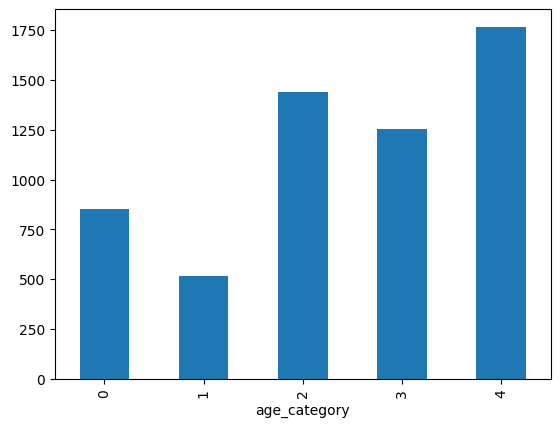

In [12]:
# Анализ целевой переменной

print(df_users['age_category'].value_counts().sort_index())
print(df_users['age_category'].value_counts(normalize=True).sort_index())
df_users['age_category'].value_counts().sort_index().plot(kind='bar')

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Нашли дисбаланс.</font>

In [13]:
target_users = set(df_users['user_id'])

for name, df in df_mains.items():
    users_in_table = set(df['user_id'])
    common_users = target_users & users_in_table
    
    print(f'{name}:')
    print(f'  пользователей в таблице: {len(users_in_table)}')
    print(f'  пересечение с df_users: {len(common_users)}')
    print(f'  отсутствуют из df_users: {len(target_users - users_in_table)}')

users:
  пользователей в таблице: 5826
  пересечение с df_users: 5826
  отсутствуют из df_users: 0
visits:
  пользователей в таблице: 5826
  пересечение с df_users: 5826
  отсутствуют из df_users: 0
ads_activity:
  пользователей в таблице: 5593
  пересечение с df_users: 5593
  отсутствуют из df_users: 233
surf_depth:
  пользователей в таблице: 5715
  пересечение с df_users: 5715
  отсутствуют из df_users: 111
primary_device:
  пользователей в таблице: 5669
  пересечение с df_users: 5669
  отсутствуют из df_users: 157
cloud_usage:
  пользователей в таблице: 5680
  пересечение с df_users: 5680
  отсутствуют из df_users: 146


In [14]:
# Анализ категориальных признаков

categorical_columns = {
    'ads_activity': ['ads_activity'],
    'surf_depth': ['surf_depth'],
    'primary_device': ['primary_device'],
    'cloud_usage': ['cloud_usage'],
    'visits': ['daytime', 'website_category']
}

for df_name, columns in categorical_columns.items():
    df = df_mains[df_name]
    
    for col in columns:
        display(df[col].value_counts(dropna=False))

ads_activity
умеренно       1824
редко          1634
часто          1069
очень редко     841
очень часто     225
Name: count, dtype: int64

surf_depth
средне          2435
поверхностно    2424
глубоко          856
Name: count, dtype: int64

primary_device
смартфон    3083
ПК          1275
ноутбук      923
планшет      388
Name: count, dtype: int64

cloud_usage
True     2951
False    2729
Name: count, dtype: int64

daytime
день     383328
вечер    376495
утро     208349
ночь      81823
Name: count, dtype: int64

website_category
Category 03    69129
Category 13    67647
Category 05    59720
Category 06    56243
Category 08    55195
Category 19    54568
Category 07    53906
Category 09    53089
Category 01    52401
Category 10    52043
Category 15    51462
Category 04    51072
Category 20    50419
Category 18    50336
Category 12    49940
Category 17    49130
Category 16    45685
Category 14    45525
Category 02    43822
Category 11    38663
Name: count, dtype: int64

In [15]:
visits_per_user = df_visits.groupby('user_id').size()

print(visits_per_user.describe())

sessions_per_user = df_visits.groupby('user_id')['session_id'].nunique()

print(sessions_per_user.describe()) # Если совпадают с предыдущим - каждая строка отдельная сессия

count    5826.000000
mean      180.225712
std        75.186802
min       100.000000
25%       124.000000
50%       167.000000
75%       213.000000
max       839.000000
dtype: float64
count    5826.000000
mean      180.225712
std        75.186802
min       100.000000
25%       124.000000
50%       167.000000
75%       213.000000
max       839.000000
Name: session_id, dtype: float64


### Промежуточный вывод по исследовательскому анализу данных

В ходе первичного анализа были изучены все исходные таблицы проекта. Основная таблица `df_users` после удаления явных дубликатов содержит 5826 уникальных пользователей. Проверка показала, что один и тот же `user_id` не относится к разным возрастным категориям, поэтому противоречий в целевой переменной не обнаружено.

Распределение целевой переменной `age_category` не является равномерным. Наиболее представлен класс `4` — пользователи старше 56 лет, а наименее представлен класс `1` — пользователи 18–25 лет. Это подтверждает необходимость использовать стратификацию при разделении данных и кросс-валидации, а также применять метрику `F1_macro`, которая одинаково учитывает качество модели на всех классах.

Дополнительные пользовательские таблицы имеют неполный охват относительно `df_users`. В таблице `df_ads_activity` отсутствуют данные для 233 пользователей, в `df_surf_depth` — для 111 пользователей, в `df_primary_device` — для 157 пользователей, в `df_cloud_usage` — для 146 пользователей. Следовательно, после объединения таблиц по `user_id` появятся пропущенные значения, которые необходимо будет обработать на этапе предобработки.

Категориальные признаки имеют ограниченное число уникальных значений и подходят для дальнейшего кодирования. В признаке `ads_activity` чаще всего встречаются значения `умеренно` и `редко`, а категория `очень часто` встречается заметно реже. В признаке `surf_depth` преобладают категории `средне` и `поверхностно`, а значение `глубоко` встречается реже. Среди основных устройств наиболее распространён смартфон. Использование облачных сервисов распределено достаточно сбалансированно.

В таблице `df_visits` представлены данные о посещениях сайтов. Чаще всего активность происходит днём и вечером, реже — ночью. Категории сайтов распределены относительно равномерно, без одной явно доминирующей категории. Это делает таблицу посещений важным источником признаков: на её основе можно построить доли активности по категориям сайтов и времени суток, а также признаки общей пользовательской активности.

Агрегированные показатели активности пользователей показывают, что минимальное количество посещений на пользователя равно 100, медианное — 167, а максимальное — 839. Это говорит о заметной вариативности интернет-активности пользователей. Такие признаки стоит использовать при формировании итогового признакового пространства.

## Предобработка данных

На этапе исследовательского анализа были обнаружены явные дубликаты в некоторых таблицах. Также было установлено, что в таблице `df_users` нет противоречий по целевой переменной: один и тот же пользователь не относится к разным возрастным категориям.

In [16]:
# Создание новых признаков на основе df_visits (так как строк очень много)

df_visits_features_base = (
    df_visits
    .groupby('user_id')
    .agg(
        visits_count=('session_id', 'count'),
        sessions_count=('session_id', 'nunique'),
        active_days=('date', 'nunique'),
        unique_website_categories=('website_category', 'nunique')
    )
    .reset_index()
)

df_visits_features_base['sessions_per_day'] = (
    df_visits_features_base['sessions_count'] / df_visits_features_base['active_days']
)

df_visits_features_base.head()

,user_id,visits_count,sessions_count,active_days,unique_website_categories,sessions_per_day
0,0010-5cf8f6b38a7b6c70a021-009dbcda,546,546,14,19,39.000000
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,185,185,14,19,13.214286
2,0014-d3032d60979a8d2b3077-f09bdce8,117,117,14,19,8.357143
3,001a-eee53e44f848608779b0-78704a67,287,287,14,19,20.500000
4,002c-40a064b12e1217e12207-a56eaf3b,490,490,14,18,35.000000


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично!  Развернули visits.</font>

In [17]:
# Доля активности по времени суток

df_daytime_share = pd.crosstab(
    index=df_visits['user_id'],
    columns=df_visits['daytime'],
    normalize='index'
).reset_index()

df_daytime_share.columns.name = None
df_daytime_share = df_daytime_share.add_prefix('daytime_share_')
df_daytime_share = df_daytime_share.rename(columns={'daytime_share_user_id': 'user_id'})

df_daytime_share.head()

,user_id,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0.413919,0.326007,0.095238,0.164835
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,0.275676,0.372973,0.086486,0.264865
2,0014-d3032d60979a8d2b3077-f09bdce8,0.307692,0.384615,0.094017,0.213675
3,001a-eee53e44f848608779b0-78704a67,0.414634,0.334495,0.108014,0.142857
4,002c-40a064b12e1217e12207-a56eaf3b,0.295918,0.383673,0.069388,0.251020


In [18]:
# Доля активности по категориям сайтов

df_category_share = pd.crosstab(
    index=df_visits['user_id'],
    columns=df_visits['website_category'],
    normalize='index'
).reset_index()

df_category_share.columns.name = None
df_category_share = df_category_share.add_prefix('website_share_')
df_category_share = df_category_share.rename(columns={'website_share_user_id': 'user_id'})

df_category_share.head()

,user_id,website_share_Category 01,website_share_Category 02,website_share_Category 03,website_share_Category 04,website_share_Category 05,website_share_Category 06,website_share_Category 07,website_share_Category 08,website_share_Category 09,...,website_share_Category 11,website_share_Category 12,website_share_Category 13,website_share_Category 14,website_share_Category 15,website_share_Category 16,website_share_Category 17,website_share_Category 18,website_share_Category 19,website_share_Category 20
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0.029304,0.000000,0.062271,0.042125,0.032967,0.053114,0.047619,0.075092,0.023810,...,0.056777,0.078755,0.021978,0.034799,0.027473,0.060440,0.051282,0.078755,0.091575,0.091575
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,0.081081,0.059459,0.027027,0.037838,0.081081,0.037838,0.048649,0.097297,0.059459,...,0.070270,0.000000,0.064865,0.037838,0.016216,0.043243,0.064865,0.086486,0.005405,0.021622
2,0014-d3032d60979a8d2b3077-f09bdce8,0.008547,0.017094,0.034188,0.059829,0.068376,0.051282,0.042735,0.017094,0.034188,...,0.000000,0.059829,0.170940,0.068376,0.059829,0.017094,0.076923,0.025641,0.102564,0.034188
3,001a-eee53e44f848608779b0-78704a67,0.066202,0.045296,0.034843,0.076655,0.034843,0.031359,0.041812,0.045296,0.045296,...,0.048780,0.066202,0.000000,0.097561,0.041812,0.031359,0.045296,0.073171,0.073171,0.059233
4,002c-40a064b12e1217e12207-a56eaf3b,0.000000,0.053061,0.071429,0.061224,0.040816,0.038776,0.059184,0.018367,0.059184,...,0.038776,0.085714,0.169388,0.000000,0.044898,0.040816,0.034694,0.012245,0.051020,0.055102


In [19]:
# Самое активное время суток и самая частая категория сайтов

df_top_daytime = (
    df_visits
    .groupby('user_id')['daytime']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'daytime': 'top_daytime'})
)

df_top_category = (
    df_visits
    .groupby('user_id')['website_category']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'website_category': 'top_website_category'})
)

In [20]:
# Обьединение

df_visits_features = (
    df_visits_features_base
    .merge(df_daytime_share, on='user_id', how='left')
    .merge(df_category_share, on='user_id', how='left')
    .merge(df_top_daytime, on='user_id', how='left')
    .merge(df_top_category, on='user_id', how='left')
)

print(df_visits_features.shape)
df_visits_features.head()

(5826, 32)


,user_id,visits_count,sessions_count,active_days,unique_website_categories,sessions_per_day,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро,...,website_share_Category 13,website_share_Category 14,website_share_Category 15,website_share_Category 16,website_share_Category 17,website_share_Category 18,website_share_Category 19,website_share_Category 20,top_daytime,top_website_category
0,0010-5cf8f6b38a7b6c70a021-009dbcda,546,546,14,19,39.000000,0.413919,0.326007,0.095238,0.164835,...,0.021978,0.034799,0.027473,0.060440,0.051282,0.078755,0.091575,0.091575,вечер,Category 19
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,185,185,14,19,13.214286,0.275676,0.372973,0.086486,0.264865,...,0.064865,0.037838,0.016216,0.043243,0.064865,0.086486,0.005405,0.021622,день,Category 08
2,0014-d3032d60979a8d2b3077-f09bdce8,117,117,14,19,8.357143,0.307692,0.384615,0.094017,0.213675,...,0.170940,0.068376,0.059829,0.017094,0.076923,0.025641,0.102564,0.034188,день,Category 13
3,001a-eee53e44f848608779b0-78704a67,287,287,14,19,20.500000,0.414634,0.334495,0.108014,0.142857,...,0.000000,0.097561,0.041812,0.031359,0.045296,0.073171,0.073171,0.059233,вечер,Category 14
4,002c-40a064b12e1217e12207-a56eaf3b,490,490,14,18,35.000000,0.295918,0.383673,0.069388,0.251020,...,0.169388,0.000000,0.044898,0.040816,0.034694,0.012245,0.051020,0.055102,день,Category 13


In [21]:
# Объединение всех признаков в один датафрейм

df = (
    df_users
    .merge(df_visits_features, on='user_id', how='left')
    .merge(df_ads_activity, on='user_id', how='left')
    .merge(df_surf_depth, on='user_id', how='left')
    .merge(df_primary_device, on='user_id', how='left')
    .merge(df_cloud_usage, on='user_id', how='left')
)

df.info()
display(df.head())

# Количество пропусков в итоговом датафрейме
print('Количество пропусков в итоговом датафрейме:')
print(df.isna().sum().sort_values(ascending=False).head(20))

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5826 non-null   str    
 1   age_category               5826 non-null   int64  
 2   visits_count               5826 non-null   int64  
 3   sessions_count             5826 non-null   int64  
 4   active_days                5826 non-null   int64  
 5   unique_website_categories  5826 non-null   int64  
 6   sessions_per_day           5826 non-null   float64
 7   daytime_share_вечер        5826 non-null   float64
 8   daytime_share_день         5826 non-null   float64
 9   daytime_share_ночь         5826 non-null   float64
 10  daytime_share_утро         5826 non-null   float64
 11  website_share_Category 01  5826 non-null   float64
 12  website_share_Category 02  5826 non-null   float64
 13  website_share_Category 03  5826 non-null   float64
 14  web

,user_id,age_category,visits_count,sessions_count,active_days,unique_website_categories,sessions_per_day,daytime_share_вечер,daytime_share_день,daytime_share_ночь,...,website_share_Category 17,website_share_Category 18,website_share_Category 19,website_share_Category 20,top_daytime,top_website_category,ads_activity,surf_depth,primary_device,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,187,187,14,19,13.357143,0.336898,0.358289,0.074866,...,0.058824,0.069519,0.074866,0.042781,день,Category 05,NaN,глубоко,смартфон,False
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,141,141,14,19,10.071429,0.390071,0.340426,0.092199,...,0.035461,0.028369,0.035461,0.035461,вечер,Category 07,умеренно,средне,смартфон,False
2,678b-614cd47d854b9d591db2-000b2e50,0,100,100,14,17,7.142857,0.380000,0.290000,0.130000,...,0.020000,0.010000,0.110000,0.060000,вечер,Category 12,умеренно,средне,смартфон,False
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,248,248,14,19,17.714286,0.258065,0.439516,0.072581,...,0.064516,0.133065,0.036290,0.012097,день,Category 18,редко,поверхностно,смартфон,True
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,119,119,14,19,8.500000,0.420168,0.344538,0.075630,...,0.050420,0.033613,0.025210,0.058824,вечер,Category 12,очень редко,поверхностно,смартфон,True


Количество пропусков в итоговом датафрейме:
ads_activity                 233
primary_device               157
cloud_usage                  146
surf_depth                   111
user_id                        0
active_days                    0
sessions_count                 0
visits_count                   0
age_category                   0
unique_website_categories      0
sessions_per_day               0
daytime_share_вечер            0
daytime_share_день             0
website_share_Category 03      0
website_share_Category 04      0
website_share_Category 05      0
website_share_Category 06      0
daytime_share_ночь             0
daytime_share_утро             0
website_share_Category 01      0
dtype: int64


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично!  Развернули visits.</font>

### Промежуточный вывод

На этапе предобработки были удалены явные дубликаты из исходных таблиц. Дата посещения сайта была приведена к типу `datetime`.

Таблица `df_visits`, изначально содержащая несколько строк на одного пользователя, была агрегирована до уровня пользователя. На её основе были созданы признаки общей активности, количества активных дней, разнообразия посещаемых категорий, среднего количества сессий в день, долей активности по времени суток и долей посещений разных категорий сайтов.

После агрегации все таблицы были объединены в единое признаковое пространство `df_features`, где одна строка соответствует одному пользователю. В итоговой таблице сохранилась целевая переменная `age_category`, идентификатор пользователя `user_id` и признаки, полученные из всех доступных источников.

После объединения в некоторых признаках появились пропущенные значения, так как дополнительные таблицы имеют неполный охват пользователей. Эти пропуски будут обработаны внутри пайплайна предобработки модели, чтобы избежать утечки данных из тестовой выборки.

In [22]:
# Поиск кандидатов на удаление:

constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) == 1
]

print("Константные столбцы:")
print(constant_columns)

duplicated_columns = df.columns[df.T.duplicated()].tolist()
print("Дублирующиеся столбцы:")
print(duplicated_columns)

print("Все значения в столбце 'visits_count' равны значениям в столбце 'sessions_count':")
print((df['visits_count'] == df['sessions_count']).all())

df = df.drop(columns=['sessions_count'])

Константные столбцы:
[]
Дублирующиеся столбцы:
['sessions_count']
Все значения в столбце 'visits_count' равны значениям в столбце 'sessions_count':
True


Признаки `visits_count` и `sessions_count` оказались полностью идентичными: количество записей о посещениях совпадает с количеством уникальных сессий для каждого пользователя. Чтобы избежать дублирования информации, признак `sessions_count` был удалён, а `visits_count` оставлен как показатель общей активности пользователя.

### Проверка корреляций

In [23]:
df_for_phik = df.drop(columns=['user_id'])

interval_cols = df_for_phik.select_dtypes(include=['int64', 'float64']).columns.tolist()

# age_category — целевая переменная
if 'age_category' in interval_cols:
    interval_cols.remove('age_category')

phik_matrix = df_for_phik.phik_matrix(interval_cols=interval_cols)

target_phik = (
    phik_matrix['age_category']
    .drop('age_category')
    .sort_values(ascending=False)
    .to_frame(name='phik_with_target')
)

display(target_phik)

,phik_with_target
daytime_share_вечер,0.686111
top_website_category,0.626992
website_share_Category 13,0.595733
daytime_share_утро,0.578419
daytime_share_день,0.566752
website_share_Category 09,0.536089
daytime_share_ночь,0.532861
website_share_Category 16,0.507852
website_share_Category 12,0.503128
website_share_Category 17,0.482861


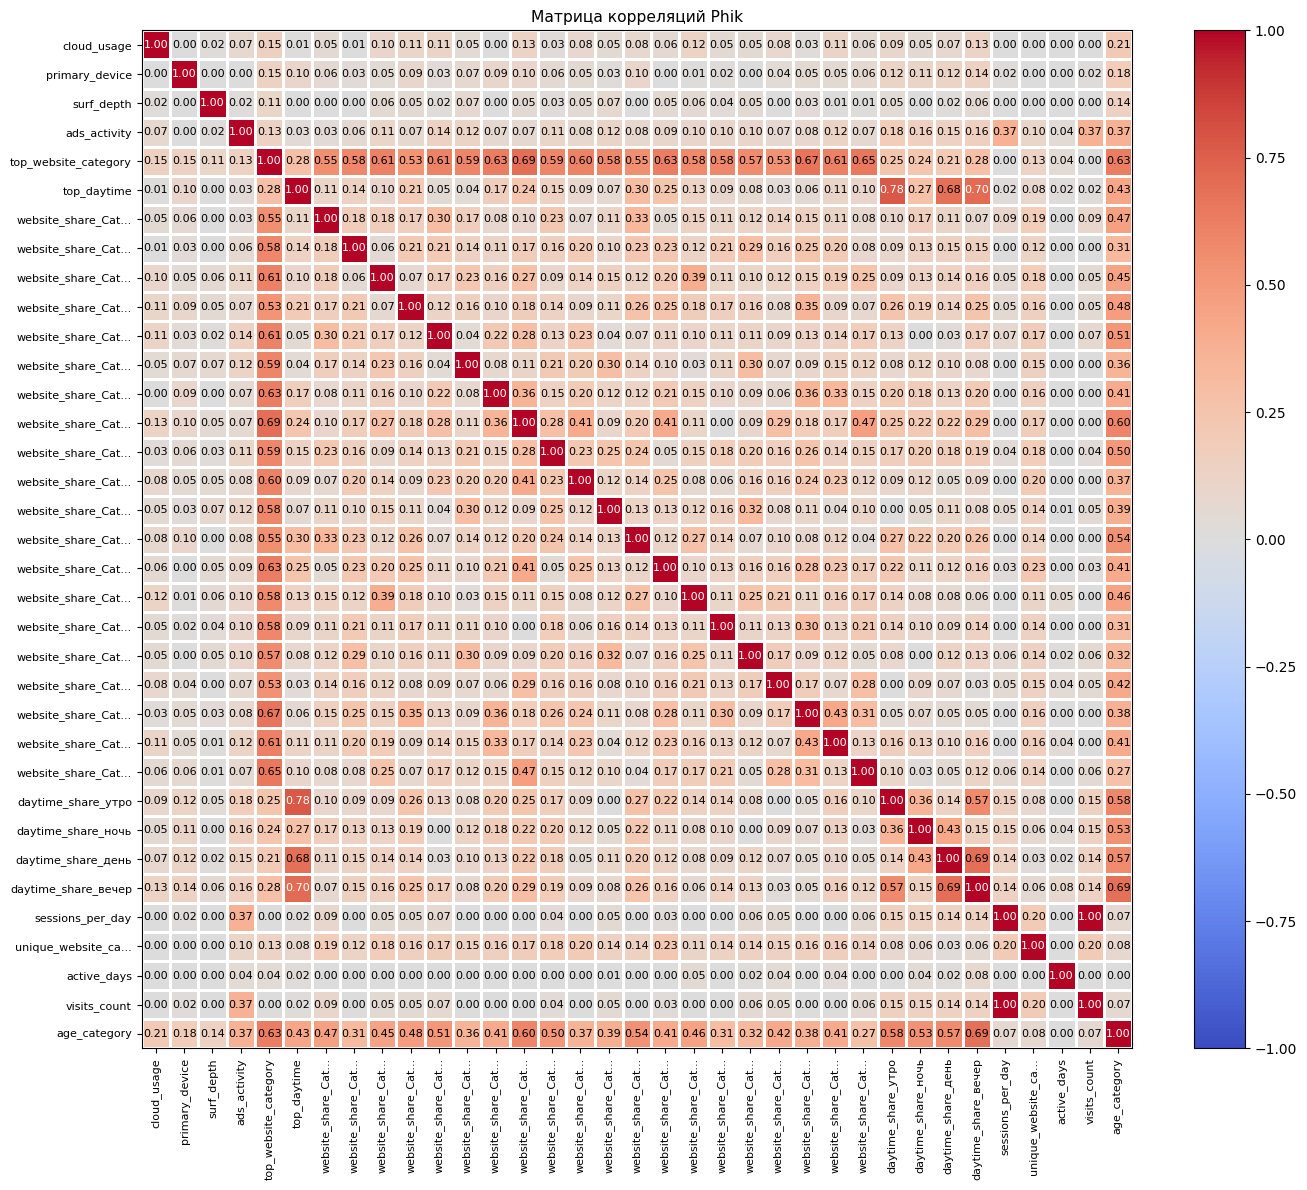

In [24]:
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    figsize=(14, 12),
    color_map='coolwarm',
    title='Матрица корреляций Phik',
    fontsize_factor=0.8
)

In [25]:
# Поиск коллинеарных признаков

high_corr_pairs = []

for i, col_1 in enumerate(phik_matrix.columns):
    for col_2 in phik_matrix.columns[i + 1:]:
        if col_1 == 'age_category' or col_2 == 'age_category':
            continue
        
        corr_value = phik_matrix.loc[col_1, col_2]
        
        if corr_value >= 0.95:
            high_corr_pairs.append((col_1, col_2, corr_value))

high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=['feature_1', 'feature_2', 'phik_corr']
).sort_values(by='phik_corr', ascending=False)

display(high_corr_pairs_df)

,feature_1,feature_2,phik_corr
0,visits_count,sessions_per_day,1.0


In [26]:
# удаляем неинформативные признаки + признаки с мультиколлинеарностью

df = df.drop(columns=['active_days', 'sessions_per_day'])

По результатам корреляционного анализа Phik признак `active_days` не показал связи с целевой переменной. Кроме того, была обнаружена полная коллинеарность между признаками `visits_count` и `sessions_per_day`.

Вероятно, это связано с тем, что число активных дней не несёт дополнительной информации, а `sessions_per_day` фактически повторяет показатель общей активности пользователя. Чтобы избежать дублирования информации, из итоговой таблицы были удалены признаки `active_days` и `sessions_per_day`. Признак `visits_count` был сохранён, так как он проще интерпретируется как общее количество посещений пользователя.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично!  Развернули visits.</font>

### Вывод по разделу

На этапе предобработки были обработаны исходные таблицы и сформировано единое признаковое пространство для дальнейшего обучения моделей.

Сначала из исходных таблиц были удалены явные дубликаты. Для таблицы `df_users` предварительно была выполнена проверка на противоречивые значения целевой переменной: один и тот же `user_id` не относился к разным возрастным категориям, поэтому удаление дубликатов не привело к потере значимой информации.

Таблица `df_visits`, изначально представленная в формате лога посещений, была агрегирована до уровня пользователя. На её основе были созданы признаки:

- общее количество посещений пользователя;
- количество активных дней;
- количество уникальных категорий посещённых сайтов;
- среднее количество сессий в день;
- доли активности по времени суток;
- доли посещений разных категорий сайтов;
- наиболее активное время суток;
- наиболее часто посещаемая категория сайтов.

После этого агрегированные признаки из `df_visits` были объединены с остальными пользовательскими таблицами: `df_ads_activity`, `df_surf_depth`, `df_primary_device` и `df_cloud_usage`. В результате была получена итоговая таблица `df`, где одна строка соответствует одному пользователю.

После объединения появились пропущенные значения в признаках из дополнительных таблиц, так как не для всех пользователей была доступна информация об активности с рекламой, глубине просмотра, основном устройстве и использовании облачных сервисов. Эти пропуски не заполнялись вручную на всём датасете, чтобы избежать утечки данных. Их обработка будет выполнена внутри пайплайна предобработки после разделения данных на обучающую и тестовую выборки.

Дополнительно был проведён корреляционный анализ с использованием коэффициента Phik. Он показал, что наиболее сильную связь с целевой переменной имеют признаки, полученные из таблицы посещений: доли активности по времени суток, доли посещений отдельных категорий сайтов и наиболее часто посещаемая категория сайта. Это подтверждает важность поведенческих признаков для решения задачи классификации возраста.

Также были выявлены признаки, не несущие дополнительной информации. Признак `active_days` не показал связи с целевой переменной, а признак `sessions_per_day` оказался полностью коллинеарен с `visits_count`. Поэтому `active_days` и `sessions_per_day` были удалены из итогового признакового пространства, а `visits_count` был сохранён как более интерпретируемый показатель общей активности пользователя.

Итоговый датафрейм подготовлен для следующего этапа: разделения данных на обучающую и тестовую выборки, построения базовой модели и оценки её качества.

## Обучение и оценка базовой модели

Hа этом этапе разделим данные на обучающую и тестовую выборки. Так как итоговая таблица `df` уже агрегирована до уровня пользователя, одна строка соответствует одному `user_id`. Тем не менее перед обучением дополнительно проверим, что один и тот же пользователь не попал одновременно в обучающую и тестовую выборки.

Разделение выполним со стратификацией по целевой переменной `age_category`, чтобы сохранить пропорции возрастных категорий в обучающей и тестовой выборках. Для оценки моделей на обучающей выборке будем использовать стратифицированную кросс-валидацию.

В качестве базовой модели используем `DummyClassifier`. Он не учитывает признаки и нужен как точка отсчёта для сравнения с более сложными моделями.

In [27]:
# разделение выборки

X = df.drop(columns=['age_category', 'user_id'])
y = df['age_category']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)

X_test, X_calib, y_test, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.375, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Размер X_train: {X_train.shape}')
print(f'Размер X_test: {X_test.shape}')
print(f'Размер X_calib: {X_calib.shape}')

print(f'Доля train: {len(X_train) / len(X):.2%}')
print(f'Доля test: {len(X_test) / len(X):.2%}')
print(f'Доля calib: {len(X_calib) / len(X):.2%}')

target_distribution = pd.DataFrame({
    'full': y.value_counts(normalize=True).sort_index(),
    'train': y_train.value_counts(normalize=True).sort_index(),
    'test': y_test.value_counts(normalize=True).sort_index(),
    'calib': y_calib.value_counts(normalize=True).sort_index()
})

display(target_distribution)


Размер X_train: (3495, 32)
Размер X_test: (1456, 32)
Размер X_calib: (875, 32)
Доля train: 59.99%
Доля test: 24.99%
Доля calib: 15.02%


,full,train,test,calib
age_category,,,,
0,0.146413,0.146495,0.146291,0.146286
1,0.088225,0.088126,0.088599,0.088000
2,0.246996,0.246924,0.247253,0.246857
3,0.215242,0.215165,0.214973,0.216000
4,0.303124,0.303290,0.302885,0.302857


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Здорово , что у нас есть выборка для тестов!</font>

In [28]:
# Типы признаков

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f'Количество числовых признаков: {len(numeric_features)}')
print(f'Количество категориальных признаков: {len(categorical_features)}')

print('\nЧисловые признаки:')
print(numeric_features)

print('\nКатегориальные признаки:')
print(categorical_features)

Количество числовых признаков: 26
Количество категориальных признаков: 6

Числовые признаки:
['visits_count', 'unique_website_categories', 'daytime_share_вечер', 'daytime_share_день', 'daytime_share_ночь', 'daytime_share_утро', 'website_share_Category 01', 'website_share_Category 02', 'website_share_Category 03', 'website_share_Category 04', 'website_share_Category 05', 'website_share_Category 06', 'website_share_Category 07', 'website_share_Category 08', 'website_share_Category 09', 'website_share_Category 10', 'website_share_Category 11', 'website_share_Category 12', 'website_share_Category 13', 'website_share_Category 14', 'website_share_Category 15', 'website_share_Category 16', 'website_share_Category 17', 'website_share_Category 18', 'website_share_Category 19', 'website_share_Category 20']

Категориальные признаки:
['top_daytime', 'top_website_category', 'ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']


C:\Users\User\AppData\Local\Temp\ipykernel_16288\2198986520.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [29]:
# Строим пайплайн

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [30]:
# Кросс-валидация и метрики

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

SCORING = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Верно, что применяется F1 macro.</font>

In [31]:
# базовая модель - DummyClassifier

dummy_model = DummyClassifier(
    strategy='most_frequent',
    random_state=RANDOM_STATE
)

dummy_cv_results = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1
)

dummy_cv_metrics = pd.DataFrame({
    'model': ['DummyClassifier'],
    'cv_f1_macro': [dummy_cv_results['test_f1_macro'].mean()],
    'cv_precision_macro': [dummy_cv_results['test_precision_macro'].mean()],
    'cv_recall_macro': [dummy_cv_results['test_recall_macro'].mean()]
})

display(dummy_cv_metrics)

,model,cv_f1_macro,cv_precision_macro,cv_recall_macro
0,DummyClassifier,0.093085,0.060658,0.2


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Классно, что сравниваешь с константной моделью!</font>

После оценки базовой модели обучим несколько простых моделей без подбора гиперпараметров. Это позволит понять, насколько признаки информативны и насколько модели, использующие данные, превосходят наивный baseline.

В качестве первых рабочих моделей используем `LogisticRegression` и `SVC`. Более тонкий отбор признаков и подбор гиперпараметров будут выполнены на следующих этапах.

In [32]:
# общая функция для моделей

def evaluate_model_cv(model_name, model, X_train, y_train, cv, scoring):
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )
    
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1
    )
    
    metrics = {
        'model': model_name,
        'cv_f1_macro': cv_results['test_f1_macro'].mean(),
        'cv_precision_macro': cv_results['test_precision_macro'].mean(),
        'cv_recall_macro': cv_results['test_recall_macro'].mean()
    }
    
    return pipeline, metrics

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Верно, что предобработка в Пайплайне при кросс-валидации.</font>

In [33]:
logreg_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

logreg_pipeline, logreg_cv_metrics = evaluate_model_cv(
    model_name='LogisticRegression',
    model=logreg_model,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    scoring=SCORING
)

In [34]:
svc_model = SVC(
    kernel='rbf',
    random_state=RANDOM_STATE
)

svc_pipeline, svc_cv_metrics = evaluate_model_cv(
    model_name='SVC_rbf',
    model=svc_model,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    scoring=SCORING
)

In [35]:
models_cv_results = pd.DataFrame([
    dummy_cv_metrics.iloc[0].to_dict(),
    logreg_cv_metrics,
    svc_cv_metrics
])

models_cv_results = models_cv_results.sort_values(
    by='cv_f1_macro',
    ascending=False
)

display(models_cv_results)

,model,cv_f1_macro,cv_precision_macro,cv_recall_macro
2,SVC_rbf,0.893639,0.899335,0.890173
1,LogisticRegression,0.836010,0.842991,0.831615
0,DummyClassifier,0.093085,0.060658,0.200000


### Вывод по обучению и оценке базовых моделей

На этом этапе данные были разделены на обучающую, тестовую и калибровочную выборки со стратификацией по целевой переменной. Для промежуточного сравнения моделей использовалась только обучающая выборка и стратифицированная кросс-валидация. Тестовая выборка не использовалась для выбора модели, отбора признаков или подбора гиперпараметров и будет применена только для финальной оценки качества.

В качестве базовой модели был использован `DummyClassifier`, который предсказывает наиболее частый класс и не использует признаки объектов. Его значение `F1_macro` на кросс-валидации составило 0.093, что ожидаемо является очень низким результатом. Эта модель служит нижней границей качества.

После этого были обучены две рабочие модели: `LogisticRegression` и `SVC` с RBF-ядром. Для них использовался единый пайплайн предобработки, включающий заполнение пропусков, масштабирование числовых признаков и кодирование категориальных признаков. Все этапы предобработки выполнялись внутри пайплайна, что позволяет избежать утечки данных при кросс-валидации.

`LogisticRegression` значительно превзошла базовую модель: значение `F1_macro` на кросс-валидации составило 0.836. Это говорит о том, что созданные признаки действительно содержат информацию, связанную с возрастной категорией пользователя.

Лучший результат на данном этапе показала модель `SVC` с RBF-ядром: `F1_macro` на кросс-валидации составила 0.894, `precision_macro` — 0.899, `recall_macro` — 0.890. Модель уже превышает минимальное требование проекта по качеству `F1_macro >= 0.75` на кросс-валидации.

Таким образом, базовые рабочие модели существенно превосходят `DummyClassifier`, а наиболее перспективной архитектурой на текущем этапе является `SVC` с RBF-ядром. Далее необходимо перейти к созданию и отбору признаков, чтобы проверить, можно ли сохранить или улучшить качество модели за счёт более компактного и информативного набора признаков.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Создание и отбор признаков

На предыдущем этапе базовые модели обучались на полном наборе признаков. В этом разделе проверим, можно ли улучшить качество модели или сделать признаковое пространство компактнее с помощью методов отбора признаков.

Будут применены три подхода:

1. Корреляционный анализ признаков на обучающей выборке.
2. Фильтрационные методы отбора:
   - `VarianceThreshold`;
   - `SelectKBest`.
3. Метод обёртки:
   - `RFE`.

Качество моделей после отбора признаков будем сравнивать с помощью стратифицированной кросс-валидации по метрике `F1_macro`.

In [36]:
# Корреляционный анализ 

df_train_analysis = X_train.copy()
df_train_analysis['age_category'] = y_train

interval_cols = df_train_analysis.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'age_category' in interval_cols:
    interval_cols.remove('age_category')

phik_matrix_train = df_train_analysis.phik_matrix(interval_cols=interval_cols)

target_phik_train = (
    phik_matrix_train['age_category']
    .drop('age_category')
    .sort_values(ascending=False)
    .to_frame(name='phik_with_target')
)

display(target_phik_train)

,phik_with_target
daytime_share_вечер,0.684651
top_website_category,0.632282
website_share_Category 13,0.603981
daytime_share_утро,0.578500
daytime_share_день,0.564503
website_share_Category 09,0.536068
daytime_share_ночь,0.524733
website_share_Category 16,0.507358
website_share_Category 12,0.493967
website_share_Category 17,0.493300


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [37]:
high_corr_pairs = []

for i, col_1 in enumerate(phik_matrix_train.columns):
    for col_2 in phik_matrix_train.columns[i + 1:]:
        if col_1 == 'age_category' or col_2 == 'age_category':
            continue
        
        corr_value = phik_matrix_train.loc[col_1, col_2]
        
        if corr_value >= 0.95:
            high_corr_pairs.append((col_1, col_2, corr_value))

high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=['feature_1', 'feature_2', 'phik_corr']
).sort_values(by='phik_corr', ascending=False)

display(high_corr_pairs_df)

,feature_1,feature_2,phik_corr


In [38]:
def evaluate_pipeline_cv(model_name, pipeline, X_train, y_train, cv, scoring):
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1
    )
    
    metrics = {
        'model': model_name,
        'cv_f1_macro': cv_results['test_f1_macro'].mean(),
        'cv_precision_macro': cv_results['test_precision_macro'].mean(),
        'cv_recall_macro': cv_results['test_recall_macro'].mean()
    }
    
    return metrics

feature_selection_results = []

In [39]:
# для сравнения

svc_full_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SVC(kernel='rbf', random_state=RANDOM_STATE))
    ]
)

svc_full_metrics = evaluate_pipeline_cv(
    model_name='SVC_full_features',
    pipeline=svc_full_pipeline,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    scoring=SCORING
)

feature_selection_results.append(svc_full_metrics)

In [40]:
variance_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('selector', VarianceThreshold(threshold=0.0)),
        ('model', SVC(kernel='rbf', random_state=RANDOM_STATE))
    ]
)

variance_metrics = evaluate_pipeline_cv(
    model_name='SVC_VarianceThreshold',
    pipeline=variance_pipeline,
    X_train=X_train,
    y_train=y_train,
    cv=cv,
    scoring=SCORING
)

feature_selection_results.append(variance_metrics)

pd.DataFrame(feature_selection_results).sort_values(by='cv_f1_macro', ascending=False)

,model,cv_f1_macro,cv_precision_macro,cv_recall_macro
0,SVC_full_features,0.893639,0.899335,0.890173
1,SVC_VarianceThreshold,0.893639,0.899335,0.890173


### Изменений не обнаружено

In [41]:
# SelectKBest:

preprocessor.fit(X_train)

feature_names_after_preprocessing = preprocessor.get_feature_names_out()
n_features_after_preprocessing = len(feature_names_after_preprocessing)

print(f'Количество признаков после предобработки: {n_features_after_preprocessing}')

Количество признаков после предобработки: 63


In [42]:
k_values = [20, 30, 40, 50, 60]

k_values = [
    k for k in k_values
    if k <= n_features_after_preprocessing
]

def mutual_info_score_func(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE
    )

In [43]:
for k in k_values:
    select_k_best_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('selector', SelectKBest(score_func=mutual_info_score_func, k=k)),
            ('model', SVC(kernel='rbf', random_state=RANDOM_STATE))
        ]
    )
    
    select_k_best_metrics = evaluate_pipeline_cv(
        model_name=f'SVC_SelectKBest_k={k}',
        pipeline=select_k_best_pipeline,
        X_train=X_train,
        y_train=y_train,
        cv=cv,
        scoring=SCORING
    )
    
    feature_selection_results.append(select_k_best_metrics)

feature_selection_results_df = (
    pd.DataFrame(feature_selection_results)
    .sort_values(by='cv_f1_macro', ascending=False)
)

display(feature_selection_results_df)

,model,cv_f1_macro,cv_precision_macro,cv_recall_macro
6,SVC_SelectKBest_k=60,0.894884,0.900897,0.891361
1,SVC_VarianceThreshold,0.893639,0.899335,0.890173
0,SVC_full_features,0.893639,0.899335,0.890173
5,SVC_SelectKBest_k=50,0.893544,0.898803,0.890430
4,SVC_SelectKBest_k=40,0.892986,0.897996,0.889789
3,SVC_SelectKBest_k=30,0.891623,0.898349,0.887303
2,SVC_SelectKBest_k=20,0.855744,0.866094,0.851065


### SelectKBest показал лучший результат при k=60

In [44]:
# RFE

rfe_n_features = [20, 30, 40, 50, 60]

rfe_n_features = [
    n for n in rfe_n_features
    if n <= n_features_after_preprocessing
]

In [45]:
# RFE + LogReg

for n_features in rfe_n_features:
    rfe_logreg_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('selector', RFE(
                estimator=LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE
                ),
                n_features_to_select=n_features
            )),
            ('model', LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            ))
        ]
    )
    
    rfe_logreg_metrics = evaluate_pipeline_cv(
        model_name=f'LogisticRegression_RFE_n={n_features}',
        pipeline=rfe_logreg_pipeline,
        X_train=X_train,
        y_train=y_train,
        cv=cv,
        scoring=SCORING
    )
    
    feature_selection_results.append(rfe_logreg_metrics)

feature_selection_results_df = (
    pd.DataFrame(feature_selection_results)
    .sort_values(by='cv_f1_macro', ascending=False)
)

display(feature_selection_results_df)

,model,cv_f1_macro,cv_precision_macro,cv_recall_macro
6,SVC_SelectKBest_k=60,0.894884,0.900897,0.891361
0,SVC_full_features,0.893639,0.899335,0.890173
1,SVC_VarianceThreshold,0.893639,0.899335,0.890173
5,SVC_SelectKBest_k=50,0.893544,0.898803,0.890430
4,SVC_SelectKBest_k=40,0.892986,0.897996,0.889789
3,SVC_SelectKBest_k=30,0.891623,0.898349,0.887303
2,SVC_SelectKBest_k=20,0.855744,0.866094,0.851065
11,LogisticRegression_RFE_n=60,0.833560,0.839490,0.829915
10,LogisticRegression_RFE_n=50,0.830088,0.836739,0.826068
9,LogisticRegression_RFE_n=40,0.817637,0.824662,0.813448


In [46]:
# RFE + SVC

for n_features in rfe_n_features:
    rfe_svc_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('selector', RFE(
                estimator=LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE
                ),
                n_features_to_select=n_features
            )),
            ('model', SVC(
                kernel='rbf',
                random_state=RANDOM_STATE
            ))
        ]
    )
    
    rfe_svc_metrics = evaluate_pipeline_cv(
        model_name=f'SVC_RFE_n={n_features}',
        pipeline=rfe_svc_pipeline,
        X_train=X_train,
        y_train=y_train,
        cv=cv,
        scoring=SCORING
    )
    
    feature_selection_results.append(rfe_svc_metrics)

feature_selection_results_df = (
    pd.DataFrame(feature_selection_results)
    .sort_values(by='cv_f1_macro', ascending=False)
)

display(feature_selection_results_df)

,model,cv_f1_macro,cv_precision_macro,cv_recall_macro
15,SVC_RFE_n=50,0.896006,0.901197,0.892564
6,SVC_SelectKBest_k=60,0.894884,0.900897,0.891361
16,SVC_RFE_n=60,0.894540,0.899534,0.891520
0,SVC_full_features,0.893639,0.899335,0.890173
1,SVC_VarianceThreshold,0.893639,0.899335,0.890173
5,SVC_SelectKBest_k=50,0.893544,0.898803,0.890430
4,SVC_SelectKBest_k=40,0.892986,0.897996,0.889789
3,SVC_SelectKBest_k=30,0.891623,0.898349,0.887303
14,SVC_RFE_n=40,0.881471,0.887362,0.877808
2,SVC_SelectKBest_k=20,0.855744,0.866094,0.851065


### Вывод по созданию и отбору признаков

В этом разделе были проверены несколько подходов к отбору признаков: корреляционный анализ, фильтрационный метод `VarianceThreshold`, фильтрационный метод `SelectKBest` и метод обёртки `RFE`.

В качестве основной модели для сравнения использовалась `SVC` с RBF-ядром, так как на предыдущем этапе она показала лучшее качество среди базовых моделей.

Метод `VarianceThreshold` не изменил качество модели: значение `F1_macro` осталось равным 0.894. Это означает, что в признаковом пространстве не было признаков с нулевой дисперсией, влияющих на результат модели.

Метод `SelectKBest` показал хорошие результаты при сохранении большого числа признаков. Лучшее качество среди вариантов `SelectKBest` было достигнуто при `k=60`: `F1_macro = 0.895`. При слишком сильном сокращении признакового пространства качество снижалось, что говорит о том, что часть признаков с умеренной индивидуальной информативностью всё же полезна модели в комбинации с другими признаками.

Лучший результат среди всех вариантов показал метод обёртки `RFE` с отбором 50 признаков: `F1_macro = 0.896`, `precision_macro = 0.901`, `recall_macro = 0.893`. Это немного выше результата модели на полном наборе признаков, где `F1_macro = 0.894`.

При этом прирост качества небольшой, поэтому нельзя сказать, что полный набор признаков был сильно избыточным. Однако `RFE` позволил немного улучшить качество и сделать признаковое пространство компактнее. Для дальнейшего подбора гиперпараметров в качестве основного варианта будет использоваться пайплайн `SVC` с отбором признаков `RFE_n=50`. Модель `SVC` на полном наборе признаков также можно оставить как контрольный вариант, так как её качество почти не уступает лучшему результату.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Подбор гиперпараметров моделей

In [47]:
# Сохраняем сюда пайплайны для удобства

logreg_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]
)

svc_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('selector', RFE(
            estimator=LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            ),
            n_features_to_select=50
        )),
        ('model', SVC(
            kernel='rbf',
            random_state=RANDOM_STATE
        ))
    ]
)

In [48]:
# Настраиваем сетки гиперпараметров (разные ядра у SVC)

param_grid_logreg = {
    "model__C": [0.1, 0.5, 1],
    "model__class_weight": [None, "balanced"]
}

param_grid_svc_linear = {
    "model__kernel": ["linear"],
    "model__C": [0.1, 0.5, 1],
    "model__class_weight": [None, "balanced"]
}

param_grid_svc_rbf = {
    "model__kernel": ["rbf"],
    "model__C": [0.5, 1, 5],
    "model__gamma": ["scale", 0.01, 0.05, 0.1],
    "model__class_weight": [None, "balanced"]
}

param_grid_svc_poly = {
    "model__kernel": ["poly"],
    "model__C": [0.5, 1],
    "model__degree": [2, 3],
    "model__gamma": ["scale", 0.05],
    "model__class_weight": [None, "balanced"]
}

models_and_grids = {
    "LogisticRegression": {
        "pipeline": logreg_pipeline,
        "param_grid": param_grid_logreg
    },
    "SVC_RFE_linear": {
        "pipeline": svc_pipeline,
        "param_grid": param_grid_svc_linear
    },
    "SVC_RFE_rbf": {
        "pipeline": svc_pipeline,
        "param_grid": param_grid_svc_rbf
    },
    "SVC_RFE_poly": {
        "pipeline": svc_pipeline,
        "param_grid": param_grid_svc_poly
    }
}

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Нужны несколько моделей SVC с разными ядрами.</font>
> Поэтому помимо LogisticRegression используйте модели опорных векторов с разными ядрами.

</span><br><span style="color: purple; font-weight: bold">Готово!</span>

In [49]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_searches = {}

for model_name, model_info in models_and_grids.items():
    print(f'\nОбучение модели: {model_name}')
    
    grid_search = GridSearchCV(
        estimator=model_info['pipeline'],
        param_grid=model_info['param_grid'],
        scoring=SCORING,
        cv=cv,
        n_jobs=-1,
        refit='f1_macro',
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    grid_searches[model_name] = grid_search
    
    print('Лучшие параметры:', grid_search.best_params_)
    print('Лучшая метрика F1_macro:', grid_search.best_score_)


Обучение модели: LogisticRegression
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшие параметры: {'model__C': 0.5, 'model__class_weight': None}
Лучшая метрика F1_macro: 0.8379708887714223

Обучение модели: SVC_RFE_linear
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшие параметры: {'model__C': 0.1, 'model__class_weight': None, 'model__kernel': 'linear'}
Лучшая метрика F1_macro: 0.8299449979876998

Обучение модели: SVC_RFE_rbf
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры: {'model__C': 1, 'model__class_weight': None, 'model__gamma': 0.05, 'model__kernel': 'rbf'}
Лучшая метрика F1_macro: 0.8972811289785609

Обучение модели: SVC_RFE_poly
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Лучшие параметры: {'model__C': 1, 'model__class_weight': 'balanced', 'model__degree': 2, 'model__gamma': 'scale', 'model__kernel': 'poly'}
Лучшая метрика F1_macro: 0.8873707289616293


In [50]:
# функция для формирования таблицы

def get_best_cv_metrics(model_name, grid_search):
    best_index = grid_search.best_index_
    
    return {
        'model': model_name,
        'cv_f1_macro': grid_search.cv_results_['mean_test_f1_macro'][best_index],
        'cv_precision_macro': grid_search.cv_results_['mean_test_precision_macro'][best_index],
        'cv_recall_macro': grid_search.cv_results_['mean_test_recall_macro'][best_index],
        'best_params': grid_search.best_params_
    }


grid_search_results = pd.DataFrame([
    get_best_cv_metrics(model_name, grid_search)
    for model_name, grid_search in grid_searches.items()
])

In [51]:
dummy_row = dummy_cv_metrics.copy()
dummy_row['best_params'] = "strategy='most_frequent'"

models_comparison = pd.concat(
    [grid_search_results, dummy_row],
    ignore_index=True
)

models_comparison = models_comparison.sort_values(
    by='cv_f1_macro',
    ascending=False
).reset_index(drop=True)

display(models_comparison)

,model,cv_f1_macro,cv_precision_macro,cv_recall_macro,best_params
0,SVC_RFE_rbf,0.897281,0.901729,0.894280,"{'model__C': 1, 'model__class_weight': None, '..."
1,SVC_RFE_poly,0.887371,0.882487,0.894021,"{'model__C': 1, 'model__class_weight': 'balanc..."
2,LogisticRegression,0.837971,0.845664,0.833464,"{'model__C': 0.5, 'model__class_weight': None}"
3,SVC_RFE_linear,0.829945,0.834321,0.827772,"{'model__C': 0.1, 'model__class_weight': None,..."
4,DummyClassifier,0.093085,0.060658,0.200000,strategy='most_frequent'


### Вывод по подбору гиперпараметров

На этом этапе был выполнен подбор гиперпараметров для нескольких архитектур моделей: `LogisticRegression`, а также моделей `SVC` с разными ядрами — `linear`, `poly` и `rbf`. Для моделей `SVC` использовался отбор признаков методом `RFE`, так как на предыдущем этапе этот подход показал лучший результат.

Подбор выполнялся с помощью `GridSearchCV` на обучающей выборке с использованием стратифицированной кросс-валидации. В качестве основной метрики использовалась `F1_macro`, так как в задаче важно одинаково учитывать качество классификации по всем возрастным категориям. Дополнительно для сравнения моделей были рассчитаны `precision_macro` и `recall_macro`.

В итоговую таблицу сравнения были включены все изученные архитектуры, включая базовую модель `DummyClassifier`. Базовая модель показала ожидаемо низкое качество: `F1_macro = 0.093`, так как она не использует признаки и предсказывает наиболее частый класс.

`LogisticRegression` после подбора гиперпараметров показала `F1_macro = 0.838`, `precision_macro = 0.846`, `recall_macro = 0.833`. Лучшие параметры модели:

- `C = 0.5`;
- `class_weight = None`.

Среди моделей опорных векторов хуже всего показала себя модель с линейным ядром: `F1_macro = 0.830`. Это говорит о том, что зависимости между признаками и возрастной категорией, вероятно, имеют нелинейный характер.

Модель `SVC` с полиномиальным ядром показала более высокое качество: `F1_macro = 0.887`, `precision_macro = 0.882`, `recall_macro = 0.894`. Однако она всё же уступила модели с RBF-ядром.

Лучший результат показала модель `SVC_RFE_rbf` со следующими параметрами:

- `C = 1`;
- `gamma = 0.05`;
- `class_weight = None`.

Для этой модели значения метрик на кросс-валидации составили:

- `F1_macro = 0.897`;
- `precision_macro = 0.902`;
- `recall_macro = 0.894`.

Таким образом, наилучшей архитектурой оказалась модель `SVC` с RBF-ядром и отбором 50 признаков методом `RFE`. Она превзошла как линейную модель, так и SVC с другими ядрами, а также значительно превысила минимальное требование проекта `F1_macro >= 0.75`.

В качестве финальной модели выбрана `SVC_RFE_rbf`. Так как `GridSearchCV` был запущен с параметром `refit='f1_macro'`, лучший пайплайн уже переобучен на всей обучающей выборке. Далее этот обученный пайплайн будет откалиброван на отдельной калибровочной выборке и затем оценён на тестовой выборке.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Нужна табличка сравнения всех оценок моделей для выбора Лучшей, включая базовую.</font>
> Выведите на экран в отсортированном табличном виде метрики на кросс-валидации для каждой изученной архитектуры модели, включая базовую.

</span><br><span style="color: purple; font-weight: bold">Таблицу добавил (сверху)</span>

In [52]:
# Фиксируем лучшую уже обученную модель после GridSearchCV

best_model_name = models_comparison.iloc[0]["model"]

print("Лучшая модель:", best_model_name)

final_svc_pipeline = grid_searches[best_model_name].best_estimator_

print("Лучшие параметры:", grid_searches[best_model_name].best_params_)
print("Лучшее значение F1_macro на CV:", grid_searches[best_model_name].best_score_)
display(final_svc_pipeline)

Лучшая модель: SVC_RFE_rbf
Лучшие параметры: {'model__C': 1, 'model__class_weight': None, 'model__gamma': 0.05, 'model__kernel': 'rbf'}
Лучшее значение F1_macro на CV: 0.8972811289785609


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'> Pipeline в `grid_search_svc.best_estimator_` уже обученный.</font>

</span><br><span style="color: purple; font-weight: bold">Чуть изменил код и формулировку</span>

In [53]:
# Калибровка и Оценка на тестовой выборке

calibrated_svc = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_svc_pipeline),
    method='sigmoid'
)

calibrated_svc.fit(X_calib, y_calib)

y_calib_proba_svc = calibrated_svc.predict_proba(X_calib)
y_test_proba_svc = calibrated_svc.predict_proba(X_test)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Отлично, что используется независимая выборка.</font>

In [54]:
y_test_pred_svc = calibrated_svc.predict(X_test)

print(classification_report(y_test, y_test_pred_svc, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       213
           1       0.82      0.77      0.79       129
           2       0.88      0.89      0.89       360
           3       0.92      0.90      0.91       313
           4       0.94      0.96      0.95       441

    accuracy                           0.90      1456
   macro avg       0.89      0.88      0.89      1456
weighted avg       0.90      0.90      0.90      1456



In [55]:
final_test_metrics = pd.DataFrame({
    'model': ['Calibrated_SVC_RFE_rbf'],
    'test_f1_macro': [f1_score(y_test, y_test_pred_svc, average='macro')],
    'test_precision_macro': [precision_score(y_test, y_test_pred_svc, average='macro', zero_division=0)],
    'test_recall_macro': [recall_score(y_test, y_test_pred_svc, average='macro')]
})

display(final_test_metrics)

,model,test_f1_macro,test_precision_macro,test_recall_macro
0,Calibrated_SVC_RFE_rbf,0.885693,0.889531,0.882254


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Тестирование проведено верно.</font>

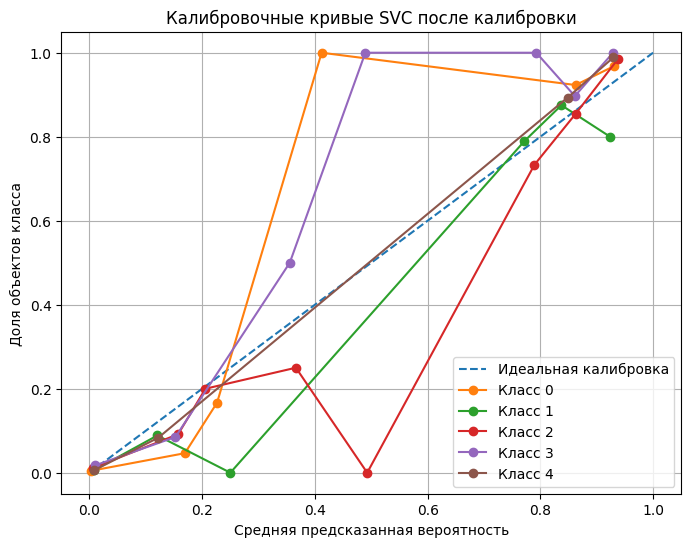

In [56]:
# Графики

classes = sorted(y_train.unique())

y_calib_binarized = label_binarize(y_calib, classes=classes)

plt.figure(figsize=(8, 6))

plt.plot([0, 1], [0, 1], linestyle='--', label='Идеальная калибровка')

for i, class_label in enumerate(classes):
    prob_true, prob_pred = calibration_curve(
        y_calib_binarized[:, i],
        y_calib_proba_svc[:, i],
        n_bins=10,
        strategy='uniform'
    )
    
    plt.plot(
        prob_pred,
        prob_true,
        marker='o',
        label=f'Класс {class_label}'
    )

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля объектов класса')
plt.title('Калибровочные кривые SVC после калибровки')
plt.legend()
plt.grid(True)
plt.show()

In [57]:
# Смотрим количественные оценки калибровки

test_log_loss = log_loss(
    y_test,
    y_test_proba_svc,
    labels=classes
)

print(f'Log Loss: {test_log_loss:.4f}')

y_test_binarized = label_binarize(y_test, classes=classes)

brier_scores = []

for i, class_label in enumerate(classes):
    score = brier_score_loss(
        y_test_binarized[:, i],
        y_test_proba_svc[:, i]
    )
    
    brier_scores.append({
        'class': class_label,
        'brier_score': score
    })

brier_scores_df = pd.DataFrame(brier_scores)

display(brier_scores_df)

print(f"Mean Brier Score: {brier_scores_df['brier_score'].mean():.4f}")

Log Loss: 0.4264


,class,brier_score
0,0,0.028579
1,1,0.031116
2,2,0.048656
3,3,0.037203
4,4,0.029610


Mean Brier Score: 0.0350


### Вывод по обучению, калибровке и оценке финальной модели

На этом этапе была подготовлена финальная модель для решения задачи классификации пользователей по возрастным категориям. В качестве итоговой модели был выбран пайплайн `SVC_RFE_rbf`, так как на предыдущих этапах он показал лучшее качество на кросс-валидации.

Финальный пайплайн включает несколько этапов:

- предобработку числовых и категориальных признаков;
- заполнение пропущенных значений;
- масштабирование числовых признаков;
- кодирование категориальных признаков;
- отбор 50 признаков методом `RFE`;
- классификатор `SVC` с RBF-ядром.

По результатам подбора гиперпараметров лучшими параметрами модели стали:

- `C = 1`;
- `gamma = 0.05`;
- `class_weight = None`.

Лучшее значение `F1_macro` на кросс-валидации составило **0.8973**. Это значение заметно превышает минимальное требование проекта `F1_macro >= 0.75`, поэтому модель можно считать достаточно качественной ещё на этапе кросс-валидации.

После выбора лучшей модели была выполнена калибровка вероятностей на отдельной калибровочной выборке. Для этого использовался `CalibratedClassifierCV` с методом `sigmoid`. Калибровочная выборка не участвовала ни в обучении базовой модели, ни в подборе гиперпараметров, что позволяет избежать утечки данных.

После калибровки модель была оценена на тестовой выборке. Итоговые значения метрик составили:

- `F1_macro` — **0.8857**;
- `precision_macro` — **0.8895**;
- `recall_macro` — **0.8823**;
- `accuracy` — **0.90**.

По отдельным возрастным категориям модель также показала стабильное качество:

- класс `0` — `f1-score = 0.89`;
- класс `1` — `f1-score = 0.79`;
- класс `2` — `f1-score = 0.89`;
- класс `3` — `f1-score = 0.91`;
- класс `4` — `f1-score = 0.95`.

Хуже всего модель справляется с классом `1`, соответствующим пользователям 18–25 лет. Это может быть связано с тем, что данный класс является самым малочисленным, а поведенческие признаки этой возрастной группы могут частично пересекаться с соседними возрастными категориями. Тем не менее качество по этому классу остаётся приемлемым: `f1-score = 0.79`.

Лучше всего модель определяет пользователей класса `4`, то есть возрастную категорию 56+ лет: для неё значение `f1-score` составило **0.95**. Также высокое качество получено для классов `0`, `2` и `3`.

Дополнительно были рассчитаны метрики качества вероятностных предсказаний после калибровки. Значение `Log Loss` составило **0.4264**, а среднее значение `Brier Score` — **0.0350**. Значения `Brier Score` по классам находились в диапазоне примерно от **0.0286** до **0.0487**, что говорит о достаточно хорошем согласовании предсказанных вероятностей с фактическими исходами.

Таким образом, финальная модель успешно проходит требования проекта: значение `F1_macro` выше 0.75 как на кросс-валидации, так и на тестовой выборке. Модель демонстрирует устойчивое качество на разных возрастных категориях и после калибровки предоставляет достаточно адекватные вероятностные оценки. Итоговый пайплайн можно использовать для дальнейшей подготовки артефактов и внедрения.

## Подготовка артефактов модели для внедрения

In [58]:
# функция сборки признаков

def build_feature_table(
    df_users,
    df_visits,
    df_ads_activity,
    df_surf_depth,
    df_primary_device,
    df_cloud_usage
):
    df_users = df_users.copy().drop_duplicates().reset_index(drop=True)
    df_visits = df_visits.copy().drop_duplicates().reset_index(drop=True)
    df_ads_activity = df_ads_activity.copy().drop_duplicates().reset_index(drop=True)
    df_surf_depth = df_surf_depth.copy().drop_duplicates().reset_index(drop=True)
    df_primary_device = df_primary_device.copy().drop_duplicates().reset_index(drop=True)
    df_cloud_usage = df_cloud_usage.copy().drop_duplicates().reset_index(drop=True)

    df_visits['date'] = pd.to_datetime(df_visits['date'])

    df_visits_features_base = (
        df_visits
        .groupby('user_id')
        .agg(
            visits_count=('session_id', 'count'),
            sessions_count=('session_id', 'nunique'),
            active_days=('date', 'nunique'),
            unique_website_categories=('website_category', 'nunique')
        )
        .reset_index()
    )

    df_visits_features_base['sessions_per_day'] = (
        df_visits_features_base['sessions_count'] / df_visits_features_base['active_days']
    )

    df_daytime_share = pd.crosstab(
        index=df_visits['user_id'],
        columns=df_visits['daytime'],
        normalize='index'
    ).reset_index()

    df_daytime_share.columns.name = None
    df_daytime_share = df_daytime_share.add_prefix('daytime_share_')
    df_daytime_share = df_daytime_share.rename(columns={'daytime_share_user_id': 'user_id'})

    df_category_share = pd.crosstab(
        index=df_visits['user_id'],
        columns=df_visits['website_category'],
        normalize='index'
    ).reset_index()

    df_category_share.columns.name = None
    df_category_share = df_category_share.add_prefix('website_share_')
    df_category_share = df_category_share.rename(columns={'website_share_user_id': 'user_id'})

    df_top_daytime = (
        df_visits
        .groupby('user_id')['daytime']
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={'daytime': 'top_daytime'})
    )

    df_top_category = (
        df_visits
        .groupby('user_id')['website_category']
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={'website_category': 'top_website_category'})
    )

    df_visits_features = (
        df_visits_features_base
        .merge(df_daytime_share, on='user_id', how='left')
        .merge(df_category_share, on='user_id', how='left')
        .merge(df_top_daytime, on='user_id', how='left')
        .merge(df_top_category, on='user_id', how='left')
    )

    df = (
        df_users
        .merge(df_visits_features, on='user_id', how='left')
        .merge(df_ads_activity, on='user_id', how='left')
        .merge(df_surf_depth, on='user_id', how='left')
        .merge(df_primary_device, on='user_id', how='left')
        .merge(df_cloud_usage, on='user_id', how='left')
    )

    columns_to_drop = [
        'sessions_count',
        'active_days',
        'sessions_per_day'
    ]

    df = df.drop(columns=columns_to_drop, errors='ignore')

    return df

In [59]:
# Функция, которая готовит вход для модели

def prepare_model_input(df_features, feature_columns):
    X = df_features.drop(columns=['age_category', 'user_id'], errors='ignore')
    X = X.reindex(columns=feature_columns)

    share_columns = [
        col for col in X.columns
        if col.startswith('daytime_share_') or col.startswith('website_share_')
    ]

    X[share_columns] = X[share_columns].fillna(0)

    return X

In [60]:
# Проверка

df_check = build_feature_table(
    df_users=df_users,
    df_visits=df_visits,
    df_ads_activity=df_ads_activity,
    df_surf_depth=df_surf_depth,
    df_primary_device=df_primary_device,
    df_cloud_usage=df_cloud_usage
)

feature_columns = list(X_train.columns)

X_check = prepare_model_input(df_check, feature_columns)

print(df_check.shape)
print(X_check.shape)
print('Колонки совпадают:', list(X_check.columns) == feature_columns)

(5826, 34)
(5826, 32)
Колонки совпадают: True


In [61]:
# Финальная калиброванная модель
calibrated_model = calibrated_svc

# Базовый pipeline, на котором строилась калибровка
base_pipeline_for_artifacts = final_svc_pipeline

# Получаем имена признаков после preprocessing
feature_names_after_preprocessing = (
    base_pipeline_for_artifacts
    .named_steps['preprocessor']
    .get_feature_names_out()
)

# Получаем маску признаков, выбранных RFE
selected_mask = (
    base_pipeline_for_artifacts
    .named_steps['selector']
    .support_
)

selected_feature_names = feature_names_after_preprocessing[selected_mask]

selected_features_info = {
    "n_selected_features": len(selected_feature_names),
    "selected_feature_names": list(selected_feature_names)
}

# Папка для артефактов внутри репозитория
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Пути к файлам
base_pipeline_path = artifacts_dir / "base_pipeline.joblib"
calibrated_model_path = artifacts_dir / "calibrated_model.joblib"
selected_features_path = artifacts_dir / "selected_features_info.joblib"
feature_columns_path = artifacts_dir / "feature_columns.joblib"
feature_builder_path = artifacts_dir / "feature_builder.pkl"

feature_builder_artifact = {
    "build_feature_table": build_feature_table,
    "prepare_model_input": prepare_model_input
}

with open(feature_builder_path, "wb") as file:
    cloudpickle.dump(feature_builder_artifact, file)

# Сохраняем артефакты
joblib.dump(base_pipeline_for_artifacts, base_pipeline_path)
joblib.dump(calibrated_model, calibrated_model_path)
joblib.dump(selected_features_info, selected_features_path)
joblib.dump(list(X_train.columns), feature_columns_path)

print("Артефакты сохранены:")
print(base_pipeline_path)
print(calibrated_model_path)
print(selected_features_path)
print(feature_columns_path)
print(feature_builder_path)

Артефакты сохранены:
artifacts\base_pipeline.joblib
artifacts\calibrated_model.joblib
artifacts\selected_features_info.joblib
artifacts\feature_columns.joblib
artifacts\feature_builder.pkl


In [62]:
# Проверка

loaded_calibrated_model = joblib.load(calibrated_model_path)

pred_before = calibrated_model.predict(X_test)
pred_after = loaded_calibrated_model.predict(X_test)

proba_before = calibrated_model.predict_proba(X_test)
proba_after = loaded_calibrated_model.predict_proba(X_test)

print("Предсказания совпадают:", np.array_equal(pred_before, pred_after))
print("Вероятности совпадают:", np.allclose(proba_before, proba_after))

Предсказания совпадают: True
Вероятности совпадают: True


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Артефакты сохранены.</font>

## Выводы о результатах работы

# Итоговый вывод

В проекте решалась задача для IT-компании «Йети», которая использует данные о поведении пользователей для настройки возрастного таргетинга в рекламной сети. Необходимо было построить модель машинного обучения, способную по цифровому следу пользователя определить его возрастную категорию.

В качестве целевой переменной использовался признак `age_category` с пятью классами:

- `0` — младше 18 лет;
- `1` — 18–25 лет;
- `2` — 26–40 лет;
- `3` — 41–55 лет;
- `4` — 56+ лет.

Исходные данные были представлены несколькими таблицами: информация о возрастной категории пользователей, логи посещений сайтов, активность взаимодействия с рекламой, глубина просмотра сайтов, основное устройство пользователя и использование облачных сервисов.

В ходе работы были выполнены основные этапы ML-проекта:

1. Загружены и изучены исходные таблицы.
2. Проведён исследовательский анализ данных.
3. Проверены пропуски, дубликаты и распределение целевой переменной.
4. Таблица посещений сайтов была агрегирована до уровня пользователя.
5. Были созданы новые поведенческие признаки:
   - общее количество посещений;
   - количество уникальных категорий сайтов;
   - доли активности по времени суток;
   - доли посещений разных категорий сайтов;
   - наиболее активное время суток;
   - наиболее часто посещаемая категория сайтов.
6. Все источники данных были объединены в единое признаковое пространство.
7. Были обучены и сравнены несколько моделей:
   - `DummyClassifier`;
   - `LogisticRegression`;
   - `SVC` с RBF-ядром.
8. Был проведён отбор признаков с помощью:
   - корреляционного анализа;
   - `VarianceThreshold`;
   - `SelectKBest`;
   - `RFE`.
9. Для лучших моделей был выполнен подбор гиперпараметров с помощью `GridSearchCV`.
10. Финальная модель была откалибрована на отдельной калибровочной выборке.
11. Были подготовлены артефакты для внедрения: модель, пайплайн, список признаков и функция формирования признакового пространства.

Базовая модель `DummyClassifier` показала очень низкое качество: `F1_macro` на кросс-валидации составила около **0.093**. Это ожидаемый результат, так как модель не использует признаки и служит только нижней границей качества.

Рабочие модели значительно превзошли baseline. `LogisticRegression` показала `F1_macro` около **0.836** на кросс-валидации, что уже выше минимального требования проекта. Однако лучшей архитектурой оказалась модель `SVC` с RBF-ядром.

На этапе отбора признаков лучший результат показал вариант `SVC` с отбором 50 признаков методом `RFE`: `F1_macro` на кросс-валидации составила около **0.896**. После подбора гиперпараметров качество удалось немного улучшить. Финальная модель имела следующие параметры:

- `C = 1`;
- `gamma = 0.05`;
- `class_weight = None`.

Лучшее значение `F1_macro` на кросс-валидации после подбора гиперпараметров составило **0.8973**.

После калибровки финальная модель была оценена на тестовой выборке. Итоговые метрики составили:

- `F1_macro` — **0.8857**;
- `precision_macro` — **0.8895**;
- `recall_macro` — **0.8823**;
- `accuracy` — **0.90**.

Модель показала качество выше требуемого порога `F1_macro >= 0.75` как на кросс-валидации, так и на тестовой выборке. Это означает, что модель можно рекомендовать к дальнейшему внедрению.

По отдельным классам качество распределилось следующим образом:

- класс `0` — `f1-score = 0.89`;
- класс `1` — `f1-score = 0.79`;
- класс `2` — `f1-score = 0.89`;
- класс `3` — `f1-score = 0.91`;
- класс `4` — `f1-score = 0.95`.

Лучше всего модель определяет пользователей категории `56+`, хуже всего — пользователей 18–25 лет. Вероятно, это связано с тем, что класс `1` является самым малочисленным, а поведение пользователей этой группы может быть похоже на поведение соседних возрастных категорий.

Дополнительно были оценены вероятностные предсказания модели после калибровки. Значение `Log Loss` составило **0.4264**, а средний `Brier Score` — **0.0350**. Это говорит о том, что модель не только достаточно точно классифицирует пользователей, но и выдаёт сравнительно адекватные вероятности принадлежности к классам.

### Рекомендации

Финальную модель `Calibrated_SVC_RFE_rbf` можно использовать как основу для внедрения в рекламную систему. Она показывает стабильное качество на тестовой выборке и превышает требуемый порог по основной метрике.

При внедрении важно использовать не только сохранённую модель, но и весь процесс подготовки признаков. Для этого были сохранены артефакты модели и функция формирования признакового пространства из исходных таблиц. Это необходимо, чтобы новые данные обрабатывались так же, как данные при обучении.

Также рекомендуется регулярно переобучать модель на новых данных, так как пользовательское поведение и структура интернет-активности могут меняться со временем. Особенно это важно для рекламных систем, где интересы пользователей и популярность категорий сайтов могут быстро изменяться.

### Возможные дальнейшие улучшения

В дальнейшем можно проверить несколько гипотез:

1. Улучшить качество на классе `1`, который модель определяет хуже остальных. Для этого можно попробовать дополнительные признаки, балансировку классов или отдельный анализ ошибок между соседними возрастными группами.

2. Добавить временные признаки: например, активность по дням недели, сезонность, изменение поведения пользователя во времени.

3. Проверить другие модели, которые хорошо работают с табличными данными, например градиентный бустинг.

4. Использовать более тонкую настройку гиперпараметров `SVC`, если ограничения по времени обучения позволяют расширить поиск.

5. Проанализировать ошибки модели: какие возрастные категории чаще всего путаются между собой и какие признаки характерны для таких случаев.

6. Проверить стабильность модели на новых периодах данных, чтобы убедиться, что качество не снижается при изменении пользовательского поведения.

Итоговый результат проекта можно считать успешным: построена модель, которая решает задачу многоклассовой классификации возрастной категории пользователей, превышает требуемое качество и подготовлена к сохранению и дальнейшему внедрению.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Андрей, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>

</span><br><span style="color: purple; font-weight: bold">Спасибо за ревью!</span>